# TSMC 월간 매출 — 수집(Selenium) · DB 저장 · 12개월 예측 (`TSMC_revenue_forecast_v1_1`)

**데이터 원천:** TSMC IR 페이지 (https://investor.tsmc.com/english/monthly-revenue/{연도})
- 연도별 URL 순회 크롤링 (2026년 포함, 실행 시점의 올해까지 자동)
- 크롤러는 업로드된 `TSMC_revenue_crawling.py`의 Selenium 로직 기반 (driver 재사용으로 속도 개선)
- 매출 단위: **백만 대만달러 (NT$ million)** — 사이트 표기 확인 완료, DB에 원 단위 그대로 저장
- **v1.1**: 월 파싱 버그 수정 (마침표 포함 축약형 `Jan.` `Sept.` 대응 — v1은 매년 5월만 수집되던 문제)

### 파이프라인 (단일 노트북, 위에서 아래로 실행)
1. 경로 설정 (노트북/데스크탑 공용) → 모듈 import → DB 연결
2. 월간 매출 크롤링 (Selenium, 연도별 순회)
3. **실적 저장** → **`taiwan_company_revenue`** 테이블 (신규) — PK `(ticker, target_date)`, UPSERT
   - 잠정치 → 확정치 갱신 시 자동 덮어쓰기 (UPSERT 원칙)
   - 티커 기반 공유 테이블: Compal(2324) 등 다른 대만 기업도 같은 테이블 사용
4. **DB에서 전체 시계열 로드** → 매출 흐름 시각화 (월간 추이 + YoY)
5. SARIMA / ETS / Theta / Ensemble **12개월 예측** (공용 모듈 `universal_ts_forecast_function_v2`)
6. 예측 저장 → **`taiwan_company_revenue_forecast`** 테이블 (`forecast_date` 빈티지) — Compal 노트북과 동일 스키마 공유
7. 과거+전망 시각화 / 예측 빈티지 비교

> 예측 입력을 크롤링 결과가 아닌 **DB 누적 실적**에서 로드하므로, 재실행 시 최근 연도만
> 크롤링해도(`CRAWL_START_YEAR` 조정) 과거 이력 전체가 예측에 반영됩니다.

## 1. 사용자 입력 변수 (이 셀만 수정)

In [1]:
# ==================== 사용자 입력 변수 (필요 시 여기만 수정) ====================

# --- 대상 기업 ---------------------------------------------------------------
TICKER       = "TSMC"    # DB 저장용 티커 (대만 증시 숫자 티커 "2330" 사용 원하면 여기만 변경)
COMPANY_NAME = "TSMC"    # 회사명 (DB 저장용)

# --- 크롤링 기간 -------------------------------------------------------------
CRAWL_START_YEAR = 2012
CRAWL_END_YEAR   = None   # None이면 실행 시점의 올해까지 자동 (2026 포함)
#   ※ 최초 1회 전체 수집 후에는 CRAWL_START_YEAR를 올해-1 정도로 줄여서 실행 권장
#     (실적은 DB에 누적되므로 예측에는 전체 이력이 자동 반영됨)

# --- DB 설정 ----------------------------------------------------------------
REVENUE_TABLE  = "taiwan_company_revenue"            # 대만 기업 월간 매출 실적 (신규)
FORECAST_TABLE = "taiwan_company_revenue_forecast"   # 대만 기업 매출 예측 (Compal과 공유)

# --- 예측 설정 --------------------------------------------------------------
RUN_FORECAST = True   # False면 수집/저장/시각화만 수행
HORIZON      = 12     # 예측 개월 수
SEASONAL_M   = 12     # 월간 계절주기
MIN_OBS      = 36     # 예측에 필요한 최소 관측 개월 수 (3년)

# --- 시각화 설정 ------------------------------------------------------------
PLOT_YEARS_BACK = 5   # 과거+전망 차트에 표시할 과거 연수

## 2. 경로 설정 (노트북 / 데스크탑 공용)
`DATA` 폴더를 자동 탐색해 프로젝트 루트와 함께 `sys.path`에 추가하고, 실패 시 두 PC의 고정 경로로 fallback합니다.

In [2]:
import sys
import os
from pathlib import Path

# 두 PC의 알려진 DATA 폴더 경로 (fallback용)
KNOWN_DATA_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA",
]

def setup_universal_paths():
    """어떤 PC에서도 작동하는 범용 경로 설정: DATA 폴더 자동 탐색 + 고정 경로 fallback"""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        data_folder = parent / "DATA"
        if data_folder.exists():
            for p in (str(parent), str(data_folder)):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로 설정] 자동 탐색 성공 | 프로젝트 루트: {parent}")
            print(f"[경로 설정] DATA 폴더: {data_folder}")
            return str(data_folder)
    for dp in KNOWN_DATA_PATHS:
        if os.path.exists(dp):
            root = str(Path(dp).parent)
            for p in (root, dp):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로 설정] 고정 경로 사용 | 프로젝트 루트: {root}")
            print(f"[경로 설정] DATA 폴더: {dp}")
            return dp
    raise FileNotFoundError(
        f"DATA 폴더를 찾을 수 없습니다.\n현재 위치: {current}\n"
        f"상위 폴더에 DATA 폴더가 있는지, 또는 KNOWN_DATA_PATHS의 경로가 맞는지 확인하세요."
    )

DATA_PATH = setup_universal_paths()

[경로 설정] 자동 탐색 성공 | 프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[경로 설정] DATA 폴더: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## 3. Import 및 DB 연결

In [3]:
import logging
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# 한글 폰트 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── Selenium (TSMC IR 페이지는 JS 렌더링 → requests 불가) ────────────────────
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

# ── 기존 공용 함수 (수정 금지 모듈) ─────────────────────────────────────────
#    ※ 와일드카드 import를 "먼저" 수행 (내부 `import datetime` 등이
#      동명 클래스를 모듈로 덮어쓰는 shadowing 방지 — 수출 노트북 v7에서 확인된 이슈)
from DATA.stock_invest_function import *  # get_db_host 등
from universal_ts_forecast_function_v2 import (
    forecast_sarima,
    forecast_ets,
    forecast_theta,
)

# ── 이 노트북이 사용하는 핵심 이름들을 star import "이후"에 확정 import ──────
import time
from datetime import date, datetime, timedelta
from sqlalchemy import create_engine, text

DB_INFO = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

def get_engine_from_info(db_info: dict):
    url = (f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
           f"@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4")
    return create_engine(url, pool_recycle=3600)

engine = get_engine_from_info(DB_INFO)
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("DB 연결 성공")

DB 연결 성공


## 4. TSMC 월간 매출 크롤러 (Selenium)
업로드 원본 `TSMC_revenue_crawling.py` 기반. 개선점:
- **driver를 연도 간 재사용** (연도마다 새로 띄우지 않음 → 대폭 속도 개선)
- **[v1.1 버그 수정]** TSMC 사이트의 월 표기는 `Jan.` `Feb.` ... `Sept.` 처럼 **마침표 포함 축약형**
  ('May'만 마침표 없음) → v1은 'May'만 매칭돼 매년 5월만 수집됨. 앞 3글자 정규화 매칭으로 수정
- 진단 로직 추가: 파싱 실패 셀 출력 + 과거 연도가 12개월 미만이면 경고
- 매출 단위: **백만 대만달러** (사이트 표기 'In Millions of New Taiwan Dollars' 확인 완료)

In [4]:
# TSMC 사이트 월 표기: 'Jan.' 'Feb.' ... 'Sept.' ... 'Dec.' — 마침표 포함 축약형 ('May'만 마침표 없음)
# v1 버그: 마침표 없는 키('Jan')로만 매칭 → 'May'만 수집됨. v1.1: 앞 3글자 정규화로 수정
MONTH_ABBR = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
              'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

def parse_month(month_text: str) -> Optional[int]:
    """월 표기 텍스트 → 1~12 정수
    대응 포맷: 'Jan.' / 'Sept.' / 'January' / 'May' / '2026/01' / '1' (실패 시 None)"""
    t = month_text.strip()
    if not t or t.lower().startswith('total'):
        return None
    m = re.match(r'[A-Za-z]+', t)
    if m:
        # 'Jan.'→'Jan', 'Sept.'→'Sep', 'January'→'Jan' : 앞 3글자로 정규화 후 매칭
        return MONTH_ABBR.get(m.group(0)[:3].capitalize())
    nums = re.findall(r'\d+', t)
    if nums:
        v = int(nums[-1])  # '2026/01' 형태면 마지막 숫자가 월
        if 1 <= v <= 12:
            return v
    return None

def parse_number(s: str) -> Optional[float]:
    """'1,234,567' → 1234567.0 / 빈 값·'-'·'--' → None"""
    t = s.strip().replace(',', '').replace('%', '')
    if not t or t in ('-', '--'):
        return None
    try:
        return float(t)
    except ValueError:
        return None

def create_driver():
    """headless Chrome driver 생성 (bot 감지 회피 옵션 포함)"""
    chrome_options = Options()
    chrome_options.add_argument('--headless')
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    chrome_options.add_argument('--disable-blink-features=AutomationControlled')
    chrome_options.add_argument(
        'user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
        '(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')
    chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
    chrome_options.add_experimental_option('useAutomationExtension', False)
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)
    driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")
    return driver

def crawl_tsmc_year(driver, year: int) -> list:
    """단일 연도 TSMC 월별 매출 크롤링 → dict 리스트 (driver는 외부에서 주입/재사용)
    단위: 백만 대만달러 (사이트 표기 'In Millions of New Taiwan Dollars')"""
    url = f"https://investor.tsmc.com/english/monthly-revenue/{year}"
    print(f"접속 중: {url}")
    driver.get(url)

    wait = WebDriverWait(driver, 15)
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "table.basicTable")))
    time.sleep(2)  # 테이블 렌더링 안정화 대기

    rows_data = []
    skipped = []   # 진단용: 파싱 실패한 첫 컬럼 텍스트 수집
    rows = driver.find_elements(By.CSS_SELECTOR, "table.basicTable tbody tr")
    for row in rows:
        cols = row.find_elements(By.TAG_NAME, "td")
        if len(cols) < 2:
            continue
        raw_month = cols[0].text
        month_num = parse_month(raw_month)
        if month_num is None:
            if raw_month.strip() and not raw_month.strip().lower().startswith('total'):
                skipped.append(raw_month.strip())
            continue
        revenue = parse_number(cols[1].text)
        if revenue is None:
            continue  # 미공시 월 (빈 셀)
        yoy = parse_number(cols[2].text) if len(cols) >= 3 else None
        rows_data.append({
            'year': year,
            'month': month_num,
            'date': f"{year}-{month_num:02d}",
            'current_sales': revenue,   # 백만 대만달러 (변환 없이 그대로)
            'yoy': yoy,
        })
    print(f"  → {year}년: {len(rows_data)}개월 수집")
    if skipped:
        print(f"  [진단] 월 파싱 실패 셀 (수집 제외됨): {skipped}")
    return rows_data

def crawl_tsmc_monthly_revenue(start_year: int, end_year: int) -> pd.DataFrame:
    """여러 연도 TSMC 월별 매출 크롤링 (driver 1개 재사용)"""
    all_data = []
    driver = None
    try:
        driver = create_driver()
        for year in range(start_year, end_year + 1):
            try:
                all_data.extend(crawl_tsmc_year(driver, year))
            except Exception as e:
                print(f"  [실패] {year}년: {e}")
            time.sleep(1)
    finally:
        if driver:
            driver.quit()

    if not all_data:
        return pd.DataFrame()

    df = pd.DataFrame(all_data).sort_values(['year', 'month']).reset_index(drop=True)
    print(f"\n총 {len(df)}개월 데이터 수집 | 기간: {df['date'].min()} ~ {df['date'].max()}")

    # ── 수집 무결성 검증: 과거 연도인데 12개월 미만이면 경고 ──
    cnt = df.groupby('year')['month'].count()
    this_year = date.today().year
    for y, n in cnt.items():
        if y < this_year and n < 12:
            print(f"[경고] {y}년 수집 {n}개월 (12개월 미만) — 파싱 누락 가능성 확인 필요")
    return df

## 5. 수집 실행

In [5]:
_end_year = CRAWL_END_YEAR if CRAWL_END_YEAR is not None else date.today().year
df = crawl_tsmc_monthly_revenue(start_year=CRAWL_START_YEAR, end_year=_end_year)

if df.empty:
    raise RuntimeError("크롤링 데이터가 없습니다. 사이트 구조 변경 또는 네트워크 상태를 확인하세요.")

print(df.tail(13).to_string())

2026-07-15 16:38:29,444 - INFO - ====== WebDriver manager ======
2026-07-15 16:38:30,726 - INFO - Get LATEST chromedriver version for google-chrome
2026-07-15 16:38:30,771 - INFO - Get LATEST chromedriver version for google-chrome
2026-07-15 16:38:30,800 - INFO - Driver [C:\Users\82108\.wdm\drivers\chromedriver\win64\150.0.7871.124\chromedriver-win32/chromedriver.exe] found in cache


접속 중: https://investor.tsmc.com/english/monthly-revenue/2012
  → 2012년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2013
  → 2013년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2014
  → 2014년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2015
  → 2015년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2016
  → 2016년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2017
  → 2017년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2018
  → 2018년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2019
  → 2019년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2020
  → 2020년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2021
  → 2021년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2022
  → 2022년: 12개월 수집
접속 중: https://investor.tsmc.com/english/monthly-revenue/2023
  → 2023년: 12개월 수집
접속 중: https://investor.tsmc.com/english/

## 6. 실적 저장 — `taiwan_company_revenue` (신규 테이블)
- PK `(ticker, target_date)` — 티커 기반 공유 테이블 (Compal 등 다른 대만 기업도 같은 테이블 사용)
- **UPSERT 원칙**: 잠정치가 확정치로 수정 공시되면 재크롤링 시 자동 덮어쓰기
- `target_date`는 월말 기준 (예측 테이블과 동일 규약)
- 이 셀의 함수는 티커-범용이므로 **Compal 노트북에 그대로 복사해 재사용 가능**

In [6]:
DDL_REVENUE = f"""
CREATE TABLE IF NOT EXISTS {REVENUE_TABLE} (
    ticker        VARCHAR(10) NOT NULL COMMENT '대만 기업 티커 (예: TSMC, 2324)',
    company_name  VARCHAR(50) NOT NULL,
    target_date   DATE        NOT NULL COMMENT '매출 대상 월 (월말)',
    revenue       BIGINT      NOT NULL COMMENT '월간 매출 (사이트 표기 단위 그대로, 변환 없음)',
    yoy           DOUBLE      NULL     COMMENT 'YoY 증감률 (%), 사이트 제공값',
    updated_at    DATETIME    NOT NULL,
    PRIMARY KEY (ticker, target_date)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
"""

UPSERT_REVENUE = text(f"""
INSERT INTO {REVENUE_TABLE}
    (ticker, company_name, target_date, revenue, yoy, updated_at)
VALUES
    (:ticker, :company_name, :target_date, :revenue, :yoy, :updated_at)
ON DUPLICATE KEY UPDATE
    revenue = VALUES(revenue),
    yoy = VALUES(yoy),
    company_name = VALUES(company_name),
    updated_at = VALUES(updated_at)
""")

def save_revenue(df_in: pd.DataFrame, ticker: str, company_name: str):
    """크롤링 결과(year/month/date/current_sales/yoy 포맷) → taiwan_company_revenue UPSERT"""
    now = datetime.now()
    rows = []
    for _, r in df_in.iterrows():
        if pd.isna(r["current_sales"]):
            continue
        target_date = (pd.to_datetime(r["date"], format="%Y-%m") + pd.offsets.MonthEnd(0)).date()
        rows.append({
            "ticker": ticker,
            "company_name": company_name,
            "target_date": target_date,
            "revenue": int(round(float(r["current_sales"]))),
            # NaN → None 치환 (astype(str) 'nan' 문제 방지 원칙과 동일: record-level pd.isna 검사)
            "yoy": None if pd.isna(r.get("yoy")) else float(r["yoy"]),
            "updated_at": now,
        })
    with engine.begin() as conn:
        conn.execute(text(DDL_REVENUE))
        conn.execute(UPSERT_REVENUE, rows)
    print(f"실적 저장 완료: {len(rows):,}행 → {REVENUE_TABLE} (ticker={ticker})")

save_revenue(df, TICKER, COMPANY_NAME)

실적 저장 완료: 174행 → taiwan_company_revenue (ticker=TSMC)


## 7. DB에서 전체 시계열 로드 + 매출 흐름 시각화
예측 입력은 크롤링 결과가 아닌 **DB 누적 실적 전체**를 사용합니다 (재실행 시 최근 연도만 크롤링해도 이력 반영).

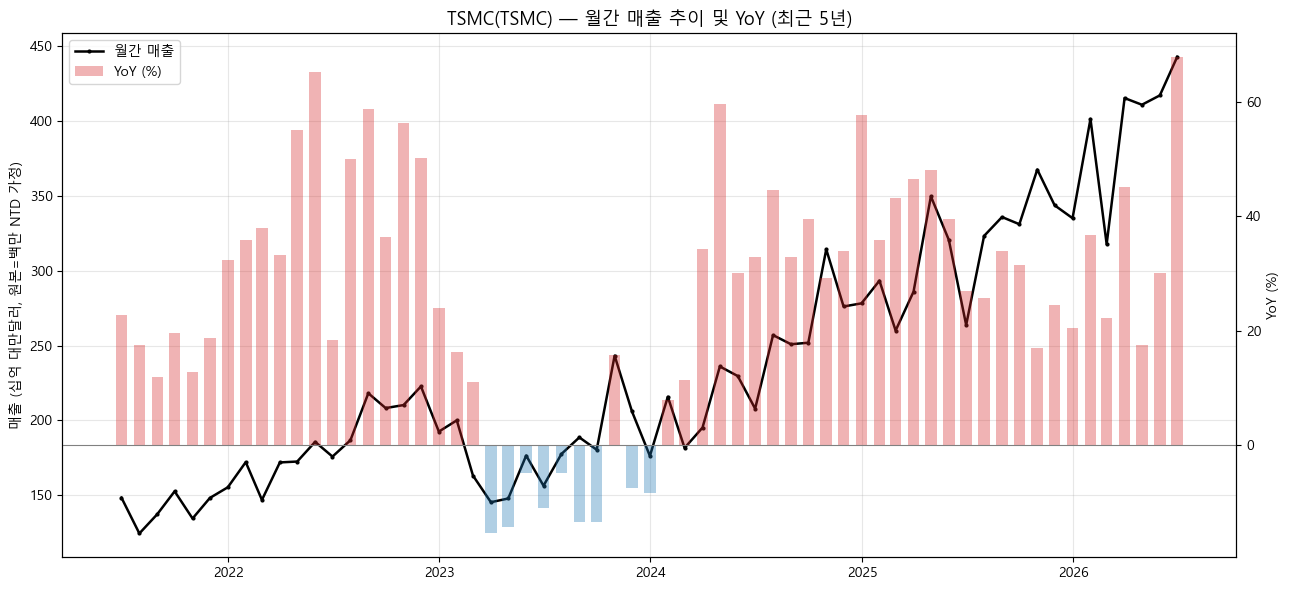

In [7]:
# pandas 버전별 월말 주기 표기 자동 감지: 1.x='M', 2.2+='ME'
try:
    pd.tseries.frequencies.to_offset("M")
    MONTH_END_FREQ = "M"
except ValueError:
    MONTH_END_FREQ = "ME"

def load_revenue_series(ticker: str) -> pd.Series:
    """taiwan_company_revenue → 월말 DatetimeIndex의 매출 pd.Series"""
    q = text(f"""
        SELECT target_date, revenue
        FROM {REVENUE_TABLE}
        WHERE ticker = :tk
        ORDER BY target_date
    """)
    d = pd.read_sql(q, engine, params={"tk": ticker})
    if d.empty:
        raise RuntimeError(f"{REVENUE_TABLE}에 ticker={ticker} 데이터가 없습니다.")
    idx = pd.DatetimeIndex(pd.to_datetime(d["target_date"]))
    s = pd.Series(d["revenue"].values.astype(float), index=idx).sort_index()
    s = s[~s.index.duplicated(keep="last")]
    s = s.asfreq(MONTH_END_FREQ)
    n_na = int(s.isna().sum())
    if n_na:
        print(f"[주의] 결측월 {n_na}개 → 선형 보간")
        s = s.interpolate(limit_direction="both")
    return s

def unit_scale(s: pd.Series):
    """차트용 자동 스케일: 원본 값 크기에 따라 (나눗셈 계수, 축 라벨) 반환 (DB 값은 변환 없이 그대로)"""
    mx = float(s.max())
    if mx >= 1e8:    # NT$ 천 단위로 추정 → 십억 NTD
        return 1e6, "매출 (십억 대만달러, 원본=천 NTD 가정)"
    elif mx >= 1e5:  # NT$ 백만 단위로 추정 → 십억 NTD
        return 1e3, "매출 (십억 대만달러, 원본=백만 NTD 가정)"
    return 1.0, "매출 (원본 단위)"

def plot_revenue_history(ticker: str, years_back: int = PLOT_YEARS_BACK):
    """월간 매출 추이 + YoY 증감률"""
    s = load_revenue_series(ticker)
    div, ylabel = unit_scale(s)
    yoy = (s / s.shift(12) - 1.0) * 100
    cut = s.index[-1] - pd.DateOffset(years=years_back)
    s_p, yoy_p = s[s.index >= cut], yoy[yoy.index >= cut]

    fig, ax1 = plt.subplots(figsize=(13, 6))
    ax2 = ax1.twinx()
    colors = ["tab:red" if v >= 0 else "tab:blue" for v in yoy_p.fillna(0)]
    ax2.bar(yoy_p.index, yoy_p.values, width=20, color=colors, alpha=0.35, label="YoY (%)")
    ax2.axhline(0, color="gray", lw=0.8)
    ax1.plot(s_p.index, s_p.values / div, color="black", lw=1.8, marker=".", ms=4,
             label="월간 매출", zorder=5)
    ax1.set_ylabel(ylabel)
    ax2.set_ylabel("YoY (%)")
    ax1.set_title(f"{COMPANY_NAME}({ticker}) — 월간 매출 추이 및 YoY (최근 {years_back}년)", fontsize=13)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_revenue_history(TICKER)

## 8. 12개월 시계열 예측 (SARIMA / ETS / Theta / Ensemble)
공용 모듈 `universal_ts_forecast_function_v2` 그대로 사용 (수정 금지). Ensemble = 성공 모델 단순 평균.

In [8]:
def run_revenue_forecast(ticker: str, horizon: int = HORIZON, m: int = SEASONAL_M) -> Optional[pd.DataFrame]:
    """
    DB 누적 실적 시계열에 대해 SARIMA/ETS/Theta 예측 후 Ensemble 계산.
    반환: [ticker, company_name, target_date, model, revenue] long DataFrame
    """
    s = load_revenue_series(ticker)
    if len(s) < MIN_OBS:
        print(f"[스킵] 관측 {len(s)}개월 < MIN_OBS({MIN_OBS})")
        return None

    future_idx = pd.date_range(s.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq=MONTH_END_FREQ)
    results = {}

    # ※ 함수 시그니처 규약: SARIMA는 seasonal_period=m, ETS/Theta는 m=m, 반환 dict "forecast"에서 배열 추출
    try:
        r = forecast_sarima(s, horizon, seasonal_period=m)
        results["SARIMA"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"[실패] SARIMA: {e}")
    try:
        r = forecast_ets(s, horizon, m=m)
        results["ETS"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"[실패] ETS: {e}")
    try:
        r = forecast_theta(s, horizon, m=m)
        results["THETA"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"[실패] THETA: {e}")

    if not results:
        print("[스킵] 모든 모델 실패")
        return None
    results["ENSEMBLE"] = np.mean(np.vstack(list(results.values())), axis=0)

    rows = []
    for model, arr in results.items():
        for dt_, v in zip(future_idx, arr):
            rows.append({"ticker": ticker, "company_name": COMPANY_NAME,
                         "target_date": dt_.date(), "model": model,
                         "revenue": int(round(float(v)))})
    print(f"[완료] {COMPANY_NAME}({ticker}): 모델 {sorted(results.keys())} | "
          f"예측 {future_idx[0].date()} ~ {future_idx[-1].date()}")
    return pd.DataFrame(rows)

## 9. 예측 결과 저장 — `taiwan_company_revenue_forecast` (`forecast_date` 구분값)
Compal 노트북과 **동일 DDL / 동일 테이블 공유** (PK: `forecast_date, ticker, target_date, model`).
같은 날 재실행하면 같은 빈티지에 덮어씀(의도된 동작).

In [9]:
DDL_FORECAST = f"""
CREATE TABLE IF NOT EXISTS {FORECAST_TABLE} (
    forecast_date DATE        NOT NULL COMMENT '예측 수행일 (빈티지 구분값)',
    ticker        VARCHAR(10) NOT NULL COMMENT '대만 기업 티커 (예: TSMC, 2324)',
    company_name  VARCHAR(50) NOT NULL,
    target_date   DATE        NOT NULL COMMENT '예측 대상 월 (월말)',
    model         VARCHAR(20) NOT NULL COMMENT 'SARIMA/ETS/THETA/ENSEMBLE',
    revenue       BIGINT      NOT NULL COMMENT '예측 월간 매출 (원본 단위 그대로)',
    created_at    DATETIME    NOT NULL,
    PRIMARY KEY (forecast_date, ticker, target_date, model)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
"""

UPSERT_FORECAST = text(f"""
INSERT INTO {FORECAST_TABLE}
    (forecast_date, ticker, company_name, target_date, model, revenue, created_at)
VALUES
    (:forecast_date, :ticker, :company_name, :target_date, :model, :revenue, :created_at)
ON DUPLICATE KEY UPDATE
    revenue = VALUES(revenue),
    company_name = VALUES(company_name),
    created_at = VALUES(created_at)
""")

def save_forecast(fdf: pd.DataFrame):
    forecast_date = date.today()   # 같은 날 재실행 시 같은 빈티지에 덮어씀 (의도된 동작)
    rows = fdf.to_dict("records")
    now = datetime.now()
    for r in rows:
        r["forecast_date"] = forecast_date
        r["created_at"] = now
    with engine.begin() as conn:
        conn.execute(text(DDL_FORECAST))
        conn.execute(UPSERT_FORECAST, rows)
    print(f"예측 저장 완료: {len(rows):,}행 → {FORECAST_TABLE} (forecast_date={forecast_date})")

if RUN_FORECAST:
    forecast_df = run_revenue_forecast(TICKER)
    if forecast_df is not None:
        save_forecast(forecast_df)
else:
    print("RUN_FORECAST=False — 예측 단계 생략")

[메모리] forecast_sarima 실행 전: 442.64 MB
[메모리] find_best_sarima_params 실행 전: 442.64 MB
[메모리] find_best_sarima_params 실행 후: 450.46 MB (변화: +7.82 MB)
[메모리] forecast_sarima 실행 후: 450.63 MB (변화: +7.99 MB)
[메모리] forecast_ets 실행 전: 450.63 MB
[메모리] forecast_ets 실행 후: 451.08 MB (변화: +0.45 MB)
[메모리] forecast_theta 실행 전: 451.08 MB
[메모리] forecast_theta 실행 후: 451.23 MB (변화: +0.15 MB)
[완료] TSMC(TSMC): 모델 ['ENSEMBLE', 'ETS', 'SARIMA', 'THETA'] | 예측 2026-07-31 ~ 2027-06-30
예측 저장 완료: 48행 → taiwan_company_revenue_forecast (forecast_date=2026-07-15)


## 10. 시각화 — 과거 + 향후 전망 / 예측 빈티지 비교
- `plot_history_and_forecast()`: 과거 실적 + 최신 예측 12개월 (Ensemble 굵은 선 + 개별 모델 점선)
- `plot_forecast_vintages()`: **예측일(`forecast_date`)별 예측 경로의 변화**를 실적 위에 겹쳐 기간별 비교

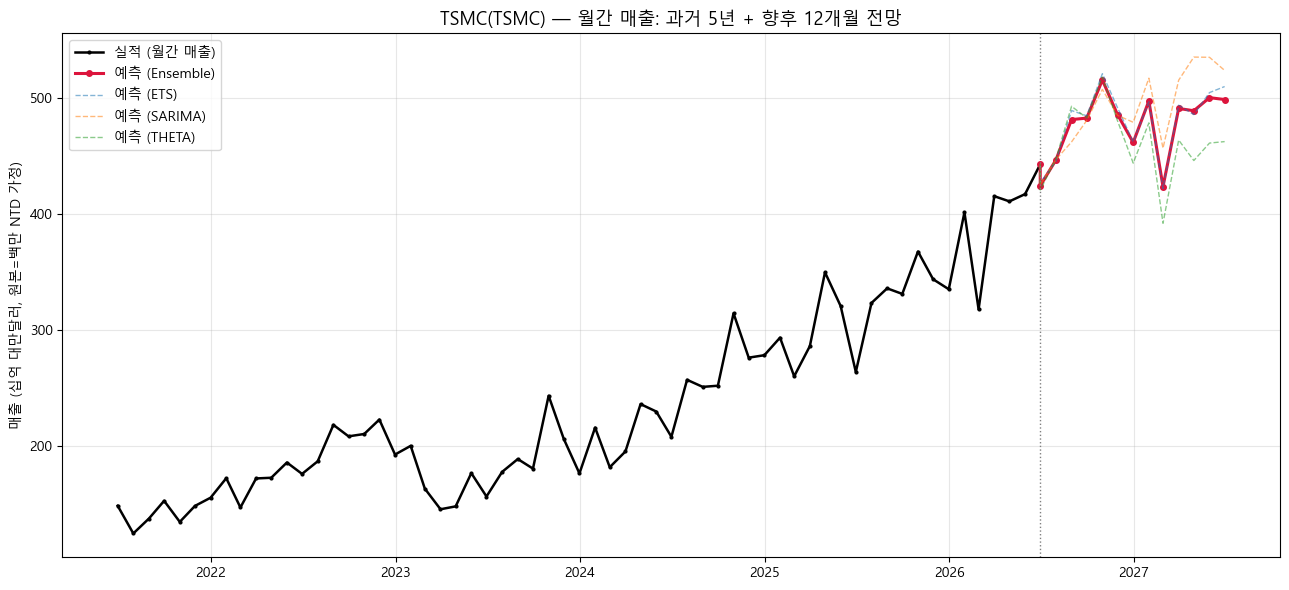

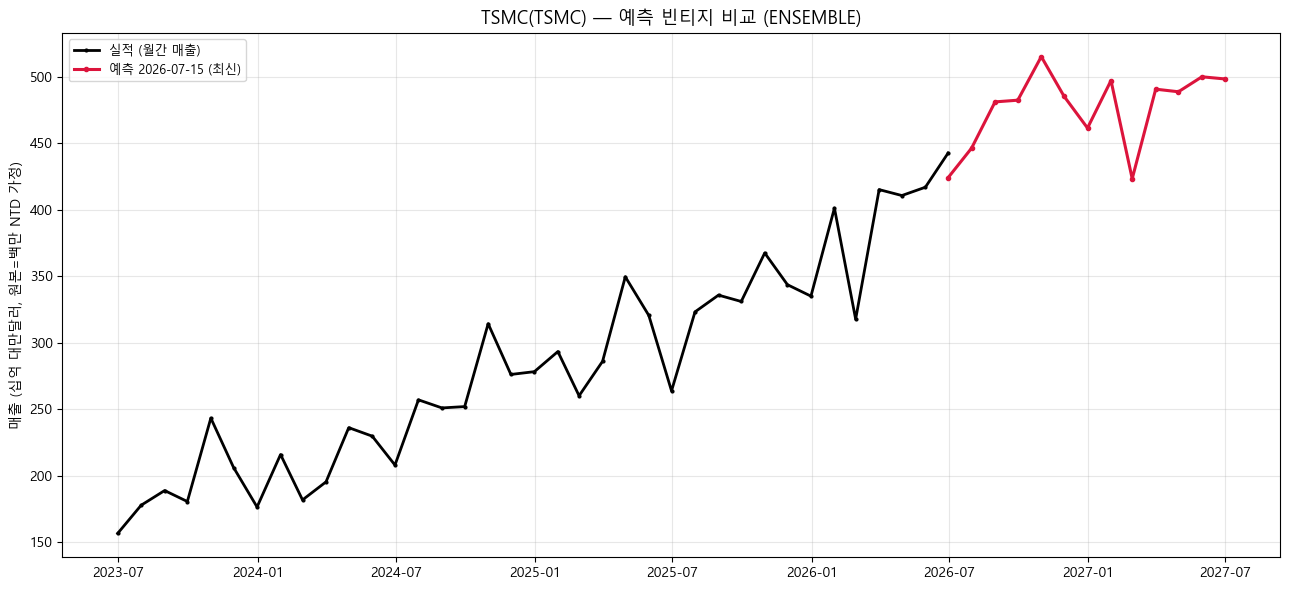

In [10]:
def plot_history_and_forecast(ticker: str, years_back: int = PLOT_YEARS_BACK,
                              show_models: bool = True):
    """과거 실적 + 최신 예측 (DB의 최신 forecast_date 빈티지)"""
    s = load_revenue_series(ticker)
    div, ylabel = unit_scale(s)
    s_plot = s[s.index >= s.index[-1] - pd.DateOffset(years=years_back)]

    fq = text(f"""
        SELECT target_date, model, revenue
        FROM {FORECAST_TABLE}
        WHERE ticker = :tk
          AND forecast_date = (SELECT MAX(forecast_date) FROM {FORECAST_TABLE} WHERE ticker = :tk)
        ORDER BY target_date
    """)
    fdf = pd.read_sql(fq, engine, params={"tk": ticker})

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(s_plot.index, s_plot.values / div, color="black", lw=1.8, marker=".", ms=4,
            label="실적 (월간 매출)")

    if not fdf.empty:
        fdf["target_date"] = pd.to_datetime(fdf["target_date"])
        bridge_x, bridge_y = s.index[-1], s.values[-1] / div
        for model, g in fdf.groupby("model"):
            x = [bridge_x] + list(g["target_date"])
            y = [bridge_y] + list(g["revenue"] / div)
            if model == "ENSEMBLE":
                ax.plot(x, y, color="crimson", lw=2.2, marker="o", ms=4, label="예측 (Ensemble)")
            elif show_models:
                ax.plot(x, y, ls="--", lw=1.0, alpha=0.55, label=f"예측 ({model})")
        ax.axvline(s.index[-1], color="gray", ls=":", lw=1)
    else:
        print("저장된 예측 없음 — 실적만 표시")

    ax.set_title(f"{COMPANY_NAME}({ticker}) — 월간 매출: 과거 {years_back}년 + 향후 {HORIZON}개월 전망",
                 fontsize=13)
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_forecast_vintages(ticker: str, n_vintages: int = 6,
                           years_back: int = 3, model: str = "ENSEMBLE"):
    """예측일별 예측 경로 변화 비교 (실적 오버레이) — 최근 n개 빈티지"""
    s = load_revenue_series(ticker)
    div, ylabel = unit_scale(s)
    s_plot = s[s.index >= s.index[-1] - pd.DateOffset(years=years_back)]

    vq = text(f"""
        SELECT DISTINCT forecast_date FROM {FORECAST_TABLE}
        WHERE ticker = :tk AND model = :model
        ORDER BY forecast_date DESC LIMIT :n
    """)
    vints = pd.read_sql(vq, engine, params={"tk": ticker, "model": model, "n": n_vintages})
    if vints.empty:
        print("저장된 예측 빈티지 없음")
        return
    vint_dates = sorted(pd.to_datetime(vints["forecast_date"]).dt.date.tolist())

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(s_plot.index, s_plot.values / div, color="black", lw=2.0, marker=".", ms=4,
            label="실적 (월간 매출)", zorder=5)

    cmap = plt.get_cmap("viridis")
    for i, fd in enumerate(vint_dates):
        fq = text(f"""
            SELECT target_date, revenue FROM {FORECAST_TABLE}
            WHERE ticker = :tk AND model = :model AND forecast_date = :fd
            ORDER BY target_date
        """)
        g = pd.read_sql(fq, engine, params={"tk": ticker, "model": model, "fd": fd})
        if g.empty:
            continue
        is_latest = (fd == vint_dates[-1])
        color = "crimson" if is_latest else cmap(i / max(len(vint_dates) - 1, 1))
        ax.plot(pd.to_datetime(g["target_date"]), g["revenue"] / div,
                color=color, lw=2.2 if is_latest else 1.1,
                alpha=1.0 if is_latest else 0.6,
                marker="o" if is_latest else None, ms=3,
                label=f"예측 {fd}" + (" (최신)" if is_latest else ""))

    ax.set_title(f"{COMPANY_NAME}({ticker}) — 예측 빈티지 비교 ({model})", fontsize=13)
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history_and_forecast(TICKER)
plot_forecast_vintages(TICKER)

## 11. 개별 모델 빈티지 비교 (선택)

In [11]:
# Ensemble 외 개별 모델의 빈티지 변화도 확인 가능
# plot_forecast_vintages(TICKER, model="SARIMA")
# plot_forecast_vintages(TICKER, model="ETS")
# plot_forecast_vintages(TICKER, model="THETA")